# Downwinding Workflow Example 3: 
- A rectangular domain and a pre-defined river network to be used for the DEM processing
- Calculating slopes with a downwinding approach to be consistent with ParFlow's OverlandFlow boundary conditon. 
- This requires two inputs: (1) a DEM and (2) a river mask

 This example usese the test domain from Condon and Maxwell (2019) (https://doi.org/10.1016/j.cageo.2019.01.020)
 the datasets for this domain are provided with the PriorityFlow R package
 to use your own datasets you should have a DEM and mask files formatted as a matrices
 with [i,j] corresponding to the x and y axes of the domain 
 (i.e. DEM[0,0] is the lower left corner of the domain and DEM[nx - 1,ny - 1] is the upper right)

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from priority_flow import (
    init_queue,
    d4_traverse_b,
    load_dem,
    load_river_mask,
    drainage_area,
    calc_subbasins,
    slope_calc_upwind,
    stream_traverse,
    find_orphan,
)

In [6]:
# DEM processing
ep = 0.01  # epsilon for stream/DEM processing

# Slope scaling
maxslope = 0.5  # maximum slope; set to -1 to disable
minslope = 1e-5  # minimum slope; set to -1 to disable
scale = 0.1  # max ratio of |secondary| / |primary| (secondaryTH)

# River and subbasin size for slope calculations
sub_th = 100  # area threshold (cells) for subbasin delineation
riv_th = sub_th  # optional: threshold for river mask for slope processing
riv_method = 3  # 0: none, 1: scale river secondary, 2: basin mean, 3: reach mean
mrg_th = 10  # merge threshold for small subbasins

# Grid dimensions for slopes
dx = 1000.0
dy = 1000.0

# Run name for outputs
runname = "Test"

# -------------------------------------------------------------------------
# Load DEM and river mask
# -------------------------------------------------------------------------
DEM = load_dem().T
river_mask = load_river_mask().T
nx, ny = DEM.shape
print(f"Domain size: nx={nx}, ny={ny}")

Domain size: nx=172, ny=215


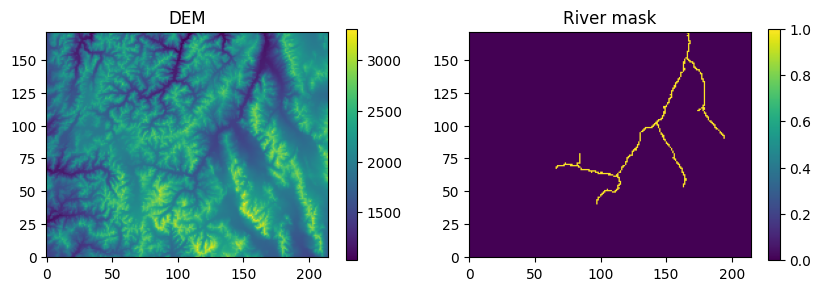

In [8]:
# Plot the inputs:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
im0 = axes[0].imshow(DEM, cmap='viridis', origin='lower')
axes[0].set_title("DEM")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(river_mask, cmap='viridis', origin='lower')
axes[1].set_title("River mask")
plt.colorbar(im1, ax=axes[1])

# Process the DEM:
1. Initialize the queue withriver cells that fall on the border
2. Traverse the stream network filling sinks and stair stepping around D8 neigbhors
3. Look for orphan branches and continue processing until they are all connected
4. Use the processed river cells as the intialize a new queue
5. process hillslopes from there

In [9]:
#1. initialize the queue with river cells that fall on the border
init = init_queue(DEM, initmask=river_mask)

No domain mask provided using entire domain
No border provided, setting border using domain mask


In [22]:
#2. take a first pass at traversing the streams
trav1 = stream_traverse(
    dem=DEM,
    mask=river_mask,
    queue=init["queue"].copy(),
    marked=init["marked"].copy(),
    basins=init["basins"].copy(),
    printstep=False,
    epsilon=ep,
)
first_pass_pct = (
    np.sum(trav1["marked"] * river_mask) / np.sum(river_mask) * 100.0
    if np.sum(river_mask) > 0
    else 0.0
)
print(f"First Pass: {first_pass_pct:.1f} % river cells processed")

First Pass: 100.0 % river cells processed


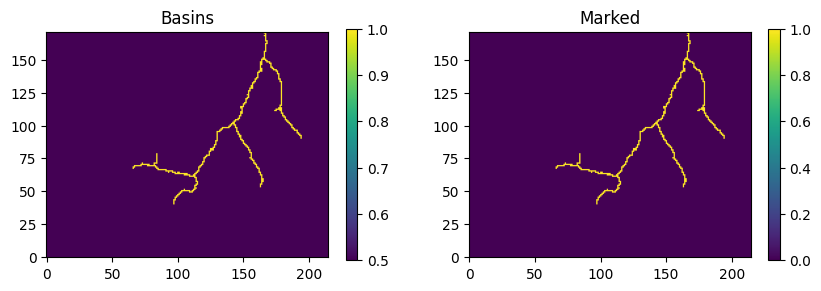

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
im0 = axes[0].imshow(trav1['basins'], vmin=0.5, vmax=np.nanmax(trav1['basins']), cmap='viridis', origin='lower')
axes[0].set_title("Basins")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(trav1['marked'], cmap='viridis', origin='lower')
axes[1].set_title("Marked")
plt.colorbar(im1, ax=axes[1])
plt.show()

In [24]:
#3. look for 'orphaned' branches and continue traversing until they are all connected
# orphaned branches are portions of the river network that are connected diagonally (i.e. without any d4 neighbors)
norphan = 1
lap = 1
while norphan > 0:
    orphan = find_orphan(
        dem=trav1["dem"],
        mask=river_mask,
        marked=trav1["marked"],
    )
    norphan = int(orphan["norphan"])
    print(f"Lap {lap}: {norphan} orphans found")

    if norphan > 0:
        trav2 = stream_traverse(
            dem=trav1["dem"],
            mask=river_mask,
            queue=orphan["queue"],
            marked=trav1["marked"],
            step=trav1["step"],
            direction=trav1["direction"],
            basins=trav1["basins"],
            printstep=False,
            epsilon=ep,
        )
        trav1 = trav2
        lap += 1
    else:
        print("Done! No orphan branches found")

final_pass_pct = (
    np.sum(trav1["marked"] * river_mask) / np.sum(river_mask) * 100.0
    if np.sum(river_mask) > 0
    else 0.0
)
print(f"Final pass: {final_pass_pct:.1f} % river cells processed")

No Orphans Found
Lap 1: 0 orphans found
Done! No orphan branches found
Final pass: 100.0 % river cells processed


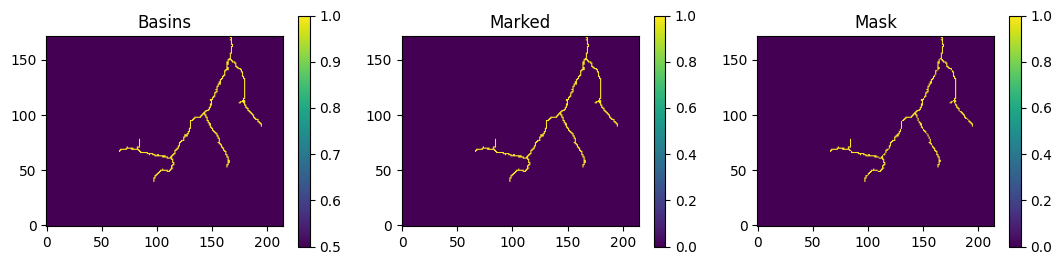

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
im0 = axes[0].imshow(trav1['basins'], vmin=0.5, vmax=np.nanmax(trav1['basins']), cmap='viridis', origin='lower')
axes[0].set_title("Basins")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(trav1['marked'], cmap='viridis', origin='lower')
axes[1].set_title("Marked")
plt.colorbar(im1, ax=axes[1])
im2 = axes[2].imshow(trav1['mask'], cmap='viridis', origin='lower')
axes[2].set_title("Mask")
plt.colorbar(im1, ax=axes[2])
plt.show()

No init mask provided all border cells will be added to queue
No domain mask provided using entire domain
No border provided, setting border using domain mask


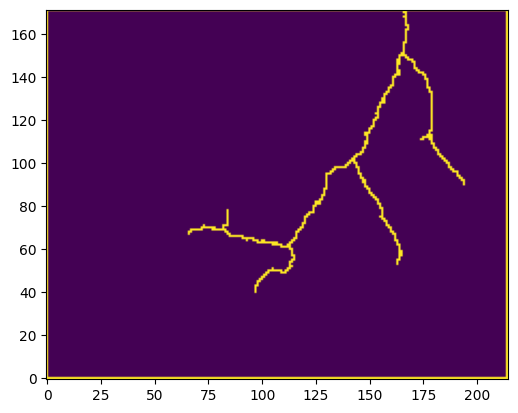

In [29]:
# 4.initialize the queue with every cell on the processed river boundary
# to do this use the marked rivers from the last step plus the edge cells
# as the boundary and the mask

inittemp = init_queue(DEM)  # rectangular boundary mask
riv_border = inittemp["marked"] + trav1["marked"]
riv_border[riv_border > 1] = 1

plt.imshow(riv_border, cmap='viridis', origin='lower')

In [30]:
init2 = init_queue(trav1["dem"], border=riv_border)

No init mask provided all border cells will be added to queue
No domain mask provided using entire domain


In [32]:
#5. process all the cells off the river usins the river as the boundary
trav_hs = d4_traverse_b(
    dem=trav1["dem"],
    queue=init2["queue"].copy(),
    marked=init2["marked"].copy(),
    direction=trav1["direction"].copy(),
    basins=trav1["basins"].copy(),
    step=trav1["step"].copy(),
    epsilon=ep,
)